In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [ ]:
df=pd.read_csv(r"C:\Users\SHILA\OneDrive\Desktop\PYTHON\ML_practiceDays\Datasets\Concrete_Data.csv")
df.sample(4)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
221,166.1,0.0,163.3,176.5,4.5,1058.6,780.1,28,21.54
668,153.0,102.0,0.0,192.0,0.0,888.0,943.1,3,4.78
290,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,14,21.50
718,122.6,183.9,0.0,203.5,0.0,958.2,800.1,7,10.35


In [4]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [5]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
df.shape

(1030, 9)

In [7]:
x=df.drop(columns=['Strength'])
y=df.iloc[:,-1]

In [8]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
lr=LinearRegression()
lr.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred=lr.predict(xtest) # all predictions stored

In [11]:
r2_score(ytest,y_pred) # accuracy of all predictions

0.6275531792314848

In [12]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring='r2')) # model/algorithm, x data, y data, scoring=name of accuracy calculator

np.float64(0.4609940491662864)

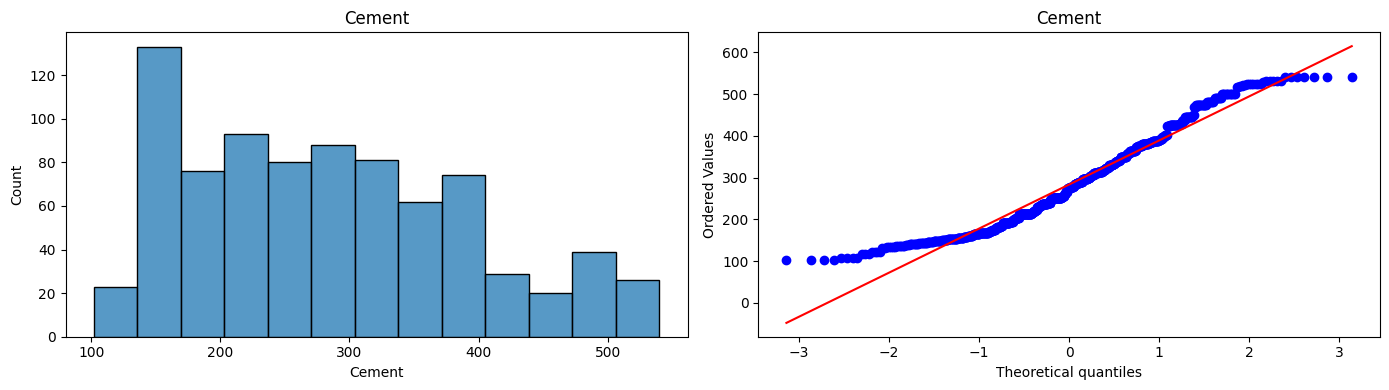

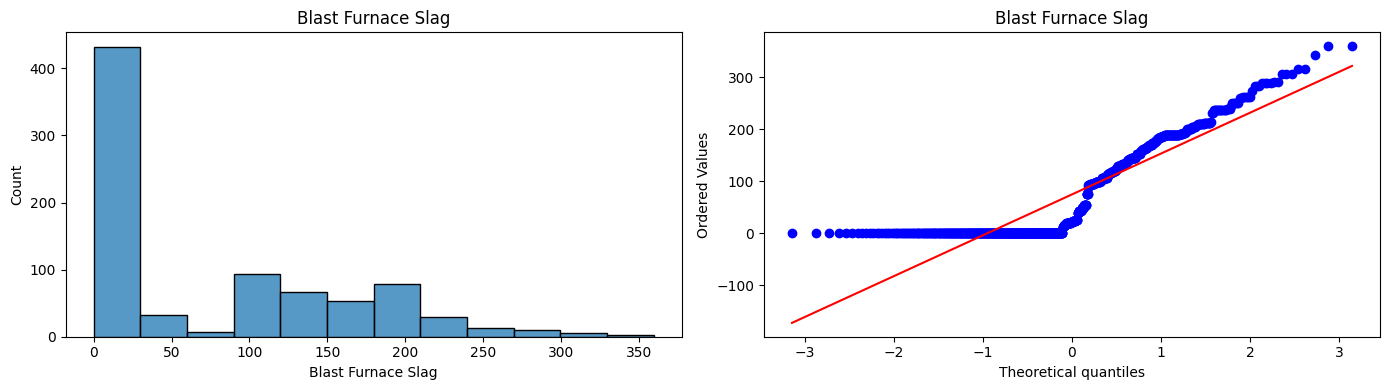

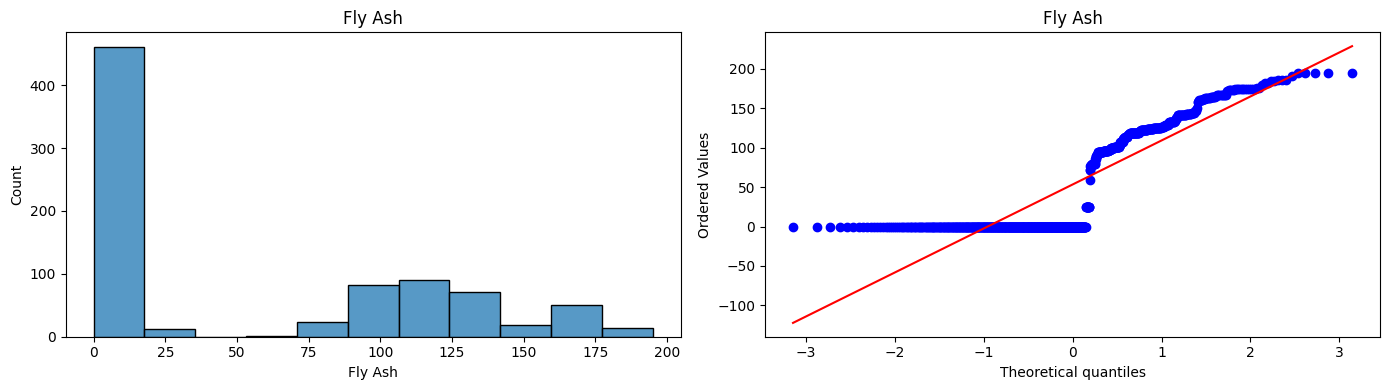

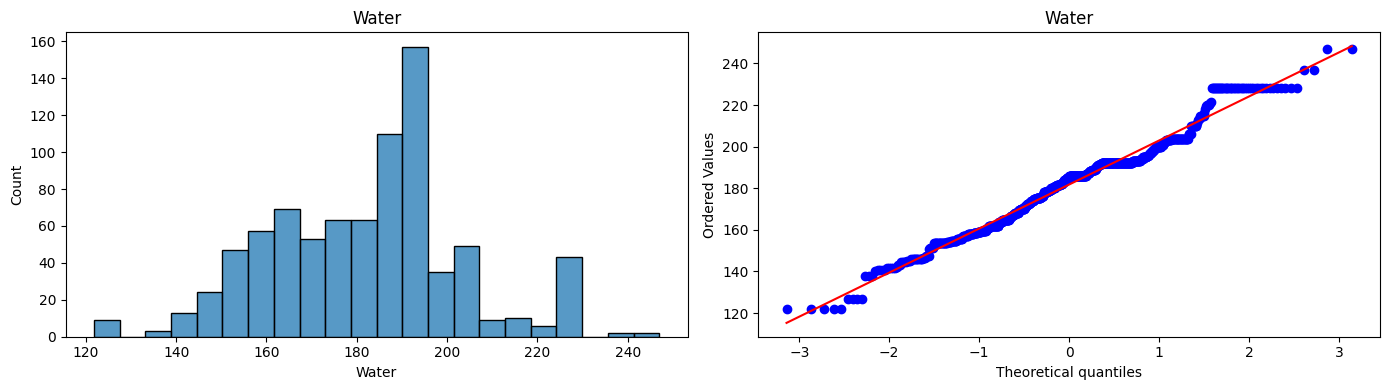

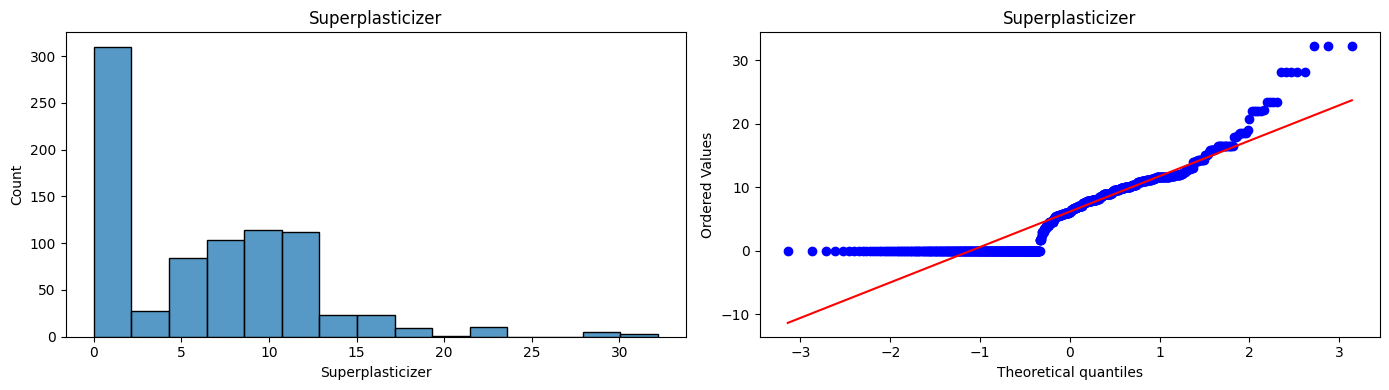

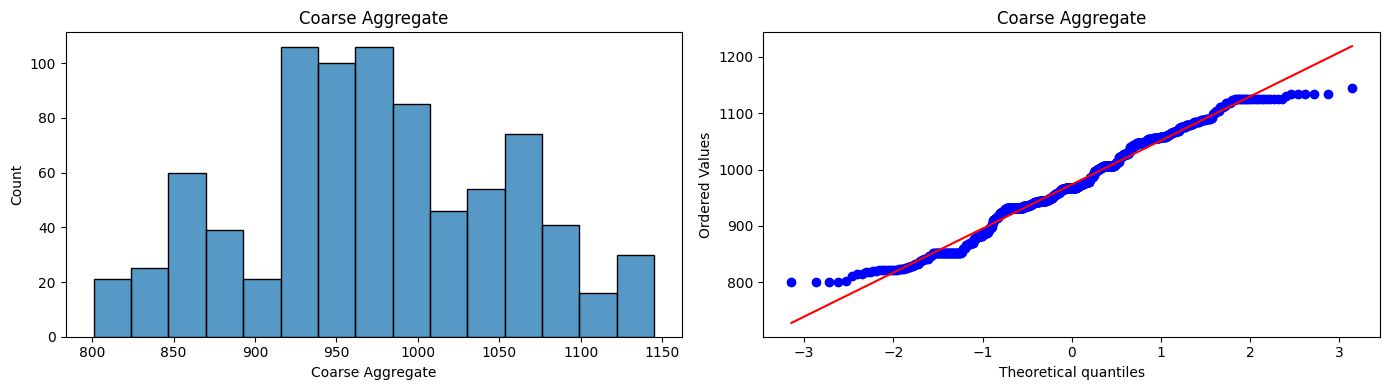

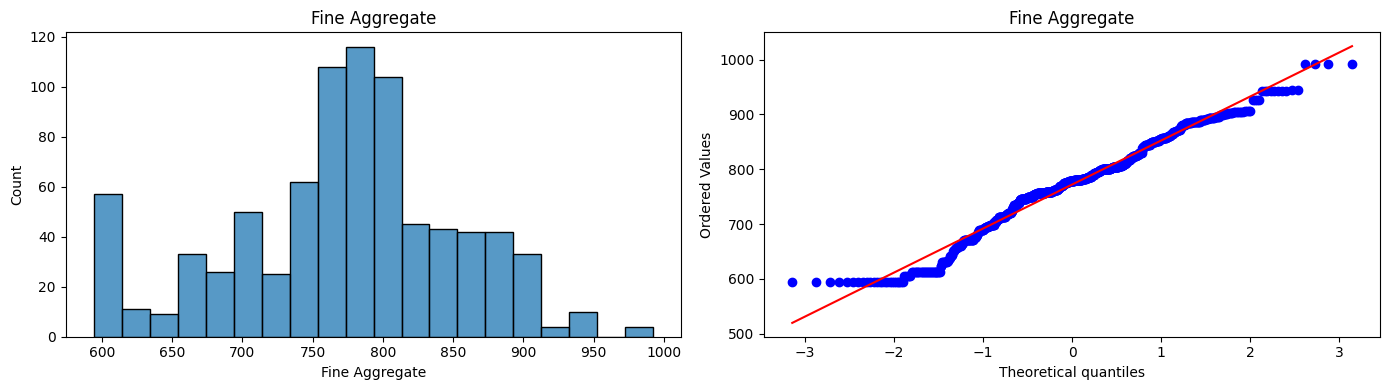

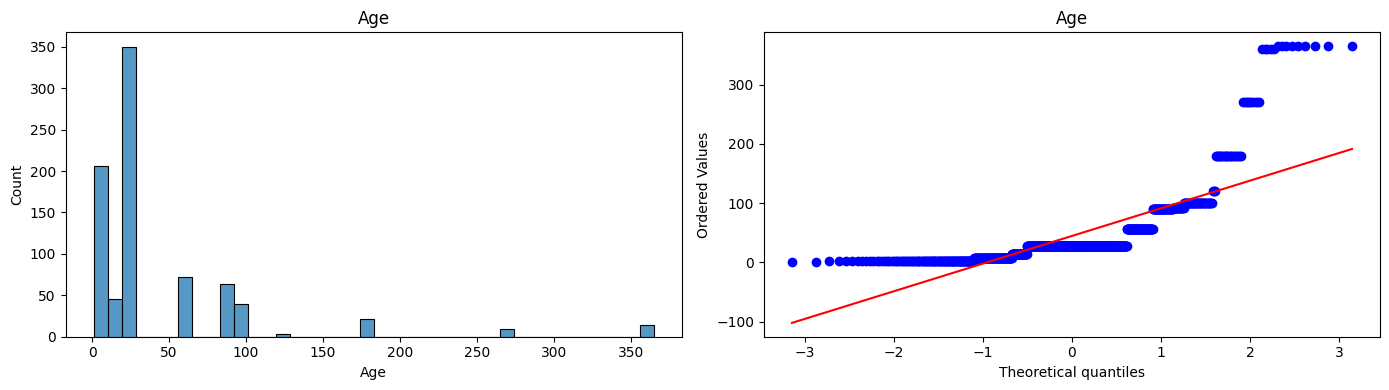

In [13]:
# plotting
for col in xtrain.columns:
    plt.figure(figsize=(14,4)) # or: fig, axes = plt.subplots(1, 2, figsize=(14, 4)), 1 row 2 columns
    plt.subplot(121)
    sns.histplot(xtrain[col]) # don't use dist plot
    plt.title(col)

    plt.subplot(122)
    stats.probplot(xtrain[col], dist="norm", plot=plt)
    plt.title(col)

    plt.tight_layout()
    plt.show()

In [14]:
# applying box-cox transformer
pt=PowerTransformer(method='box-cox') # don't work on 0, -ve values
xtrain_trans=pt.fit_transform(xtrain+0.00001)
xtest_trans=pt.transform(xtest+0.00001)

pd.DataFrame({'cols': xtrain.columns, 'box_cox_lamdas':pt.lambdas_}) # printind lambdas

,cols,box_cox_lamdas
0,Cement,0.177025
1,Blast Furnace Slag,0.027842
2,Fly Ash,-0.044554
3,Water,0.772682
4,Superplasticizer,0.113892
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066630


In [15]:
# linear model on transformed data
lr=LinearRegression()
lr.fit(xtrain_trans,ytrain)
y_pred2=lr.predict(xtest_trans)

r2_score(ytest, y_pred2)

0.8054599366864301

In [16]:
# data cross validation
pt=PowerTransformer(method='box-cox')
xtrain_trans=pt.fit_transform(x+0.00001)
xtrain_trans=pd.DataFrame(xtrain_trans, columns=xtrain.columns)

lr=LinearRegression()
np.mean(cross_val_score(lr,xtrain_trans,y,scoring='r2'))

np.float64(0.6668489654022178)

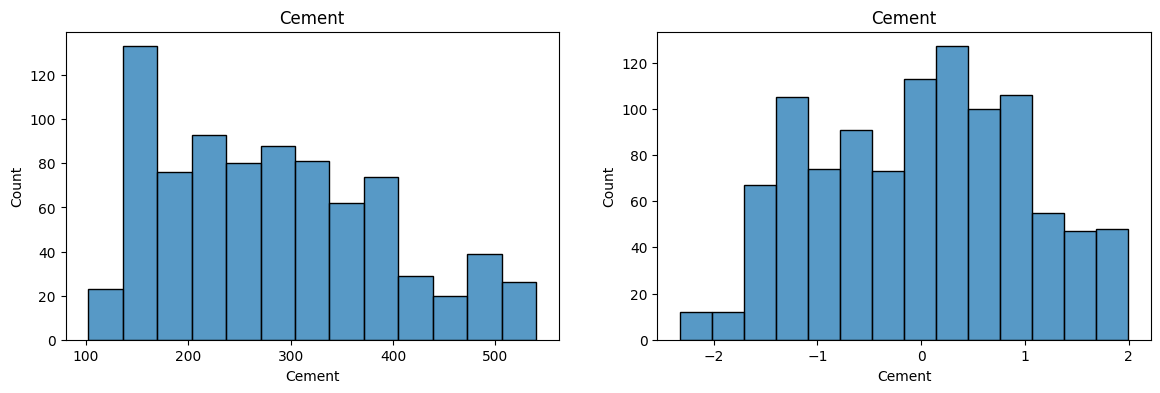

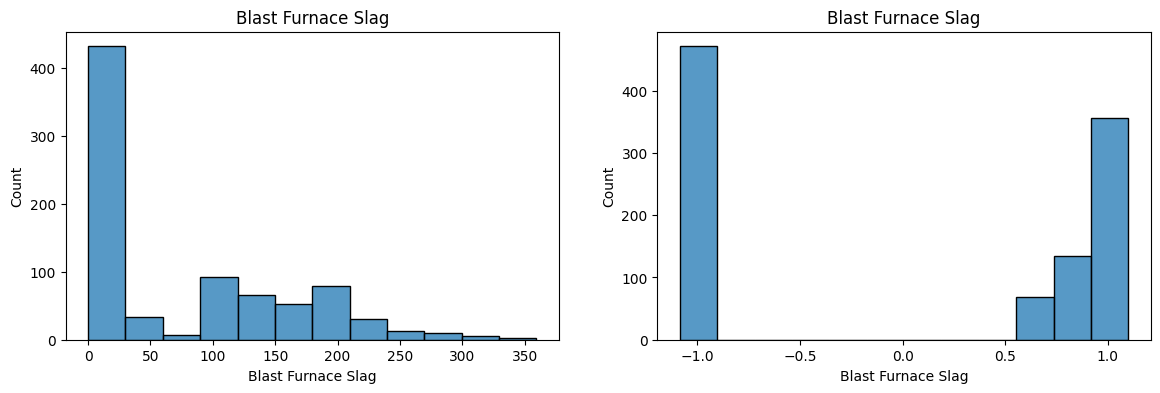

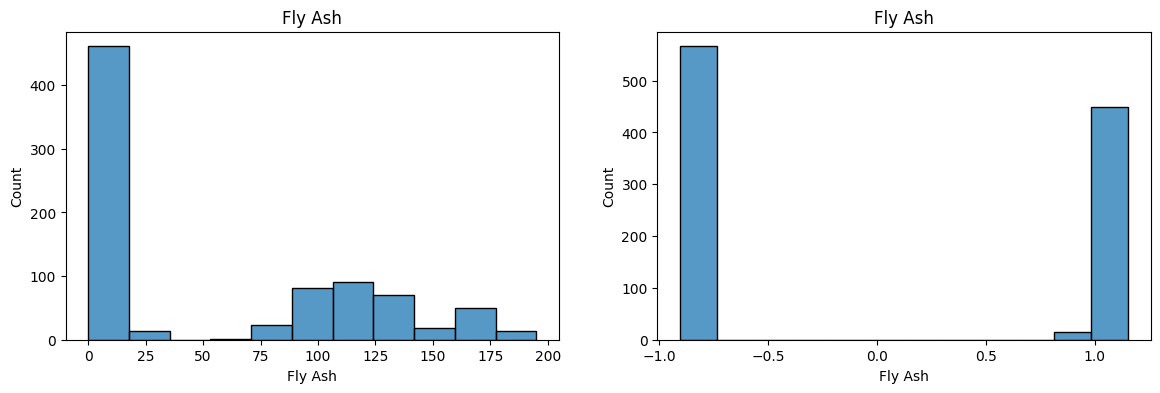

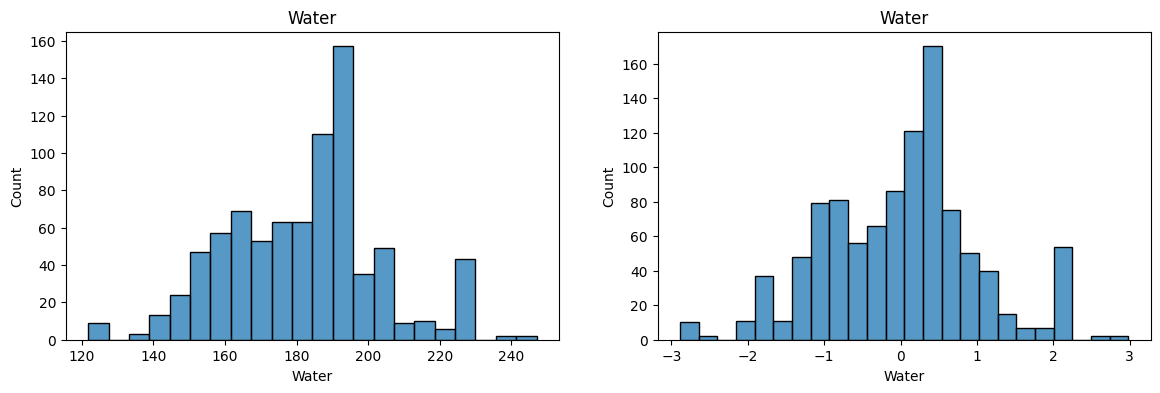

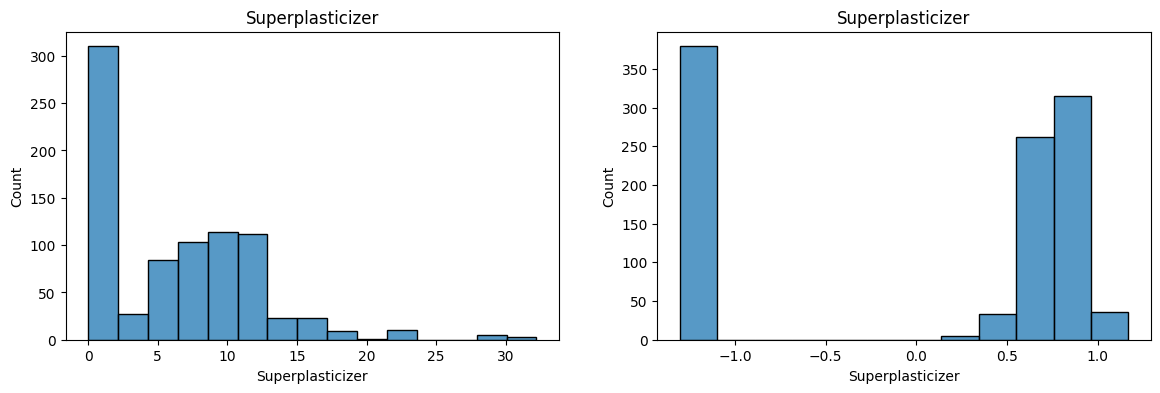

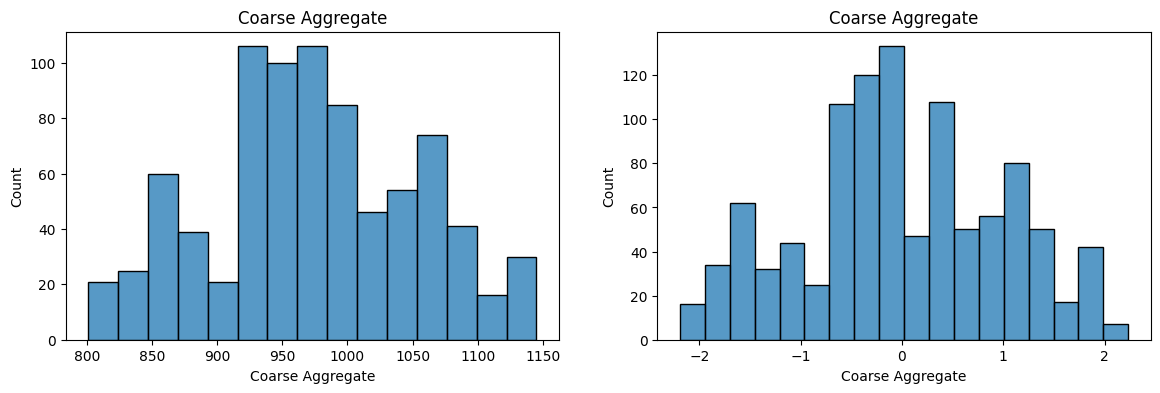

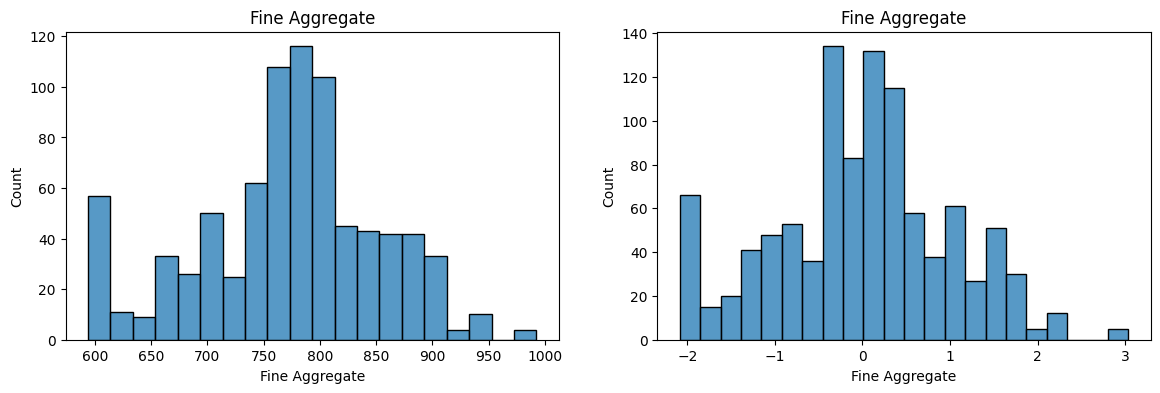

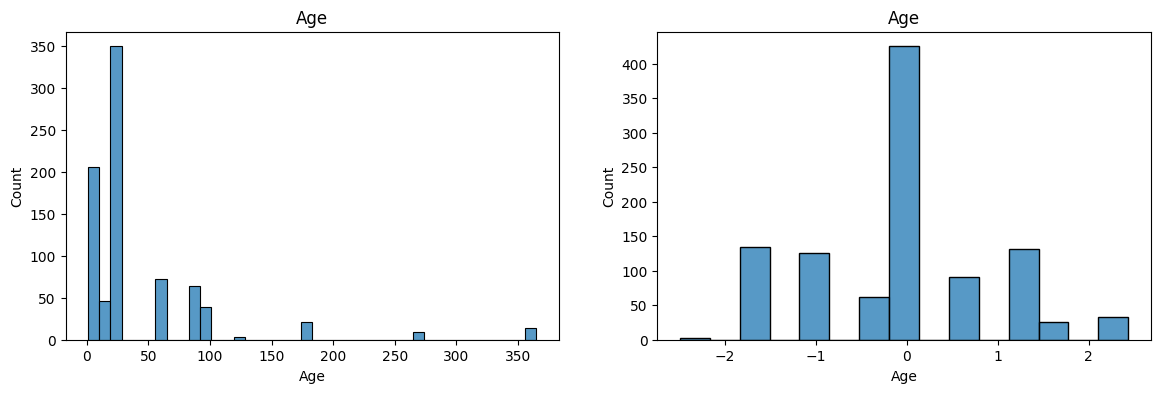

In [17]:
# before and after comparison plot for 'box-cox'
for col in xtrain_trans.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(xtrain[col])
    plt.title(col)

    plt.subplot(122)
    sns.histplot(xtrain_trans[col])
    plt.title(col)

    plt.show()

In [18]:
# apply yeo johnson
pt1=PowerTransformer() # default method is yeo johnson, better works with 0, -ve and +ve
xtrain_trans1=pt1.fit_transform(xtrain)
xtest_trans1=pt1.transform(xtest)

lr=LinearRegression()
lr.fit(xtrain_trans1,ytrain)

y_pred3=lr.predict(xtest_trans1)

print(f"Accuracy : {np.round(r2_score(ytest,y_pred3)*100,2)}%")

Accuracy : 81.62%


In [19]:
pd.DataFrame({'Columns' : xtrain.columns, 'yeo_johnson_lambdas' : pt1.lambdas_})

,Columns,yeo_johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [20]:
# cross validate
pt1=PowerTransformer()
xtrain_trans=pt1.fit_transform(x)

lr=LinearRegression()
np.mean(cross_val_score(lr, xtrain_trans,y,scoring='r2'))

np.float64(0.6834625126992433)

In [21]:
xtrain_trans=pd.DataFrame(xtrain_trans, columns=xtrain.columns)

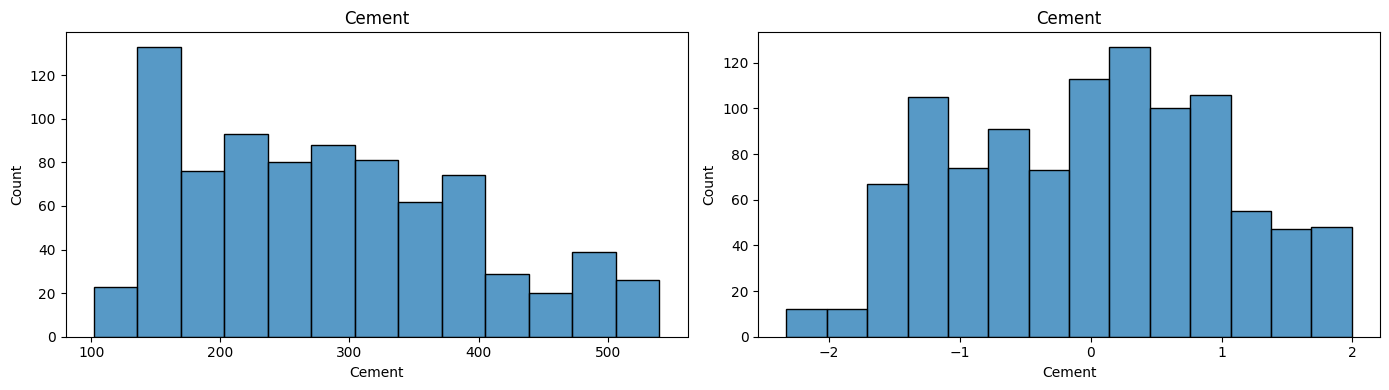

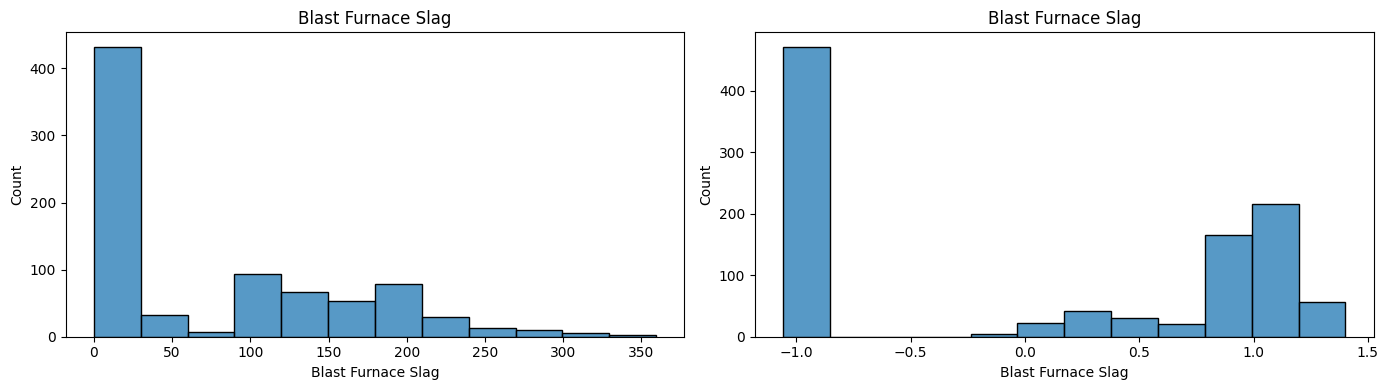

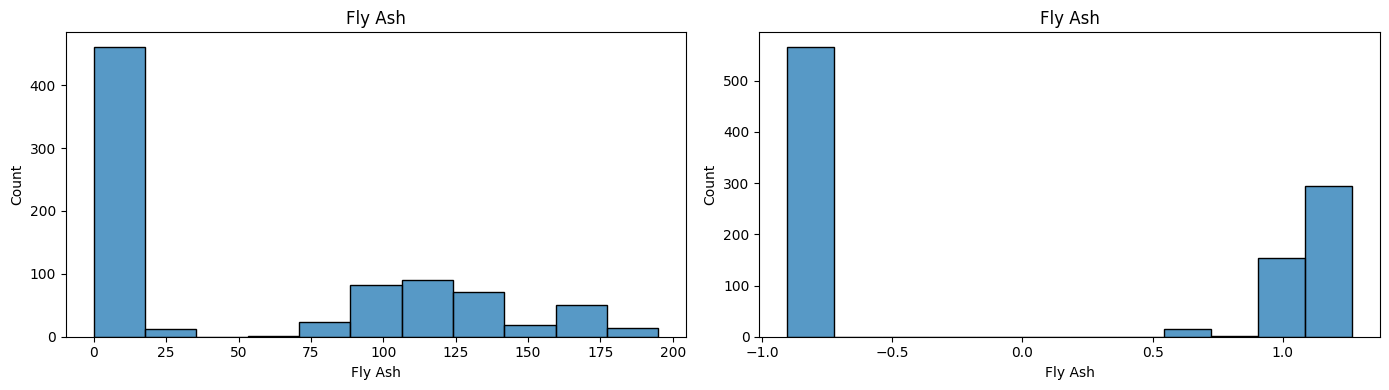

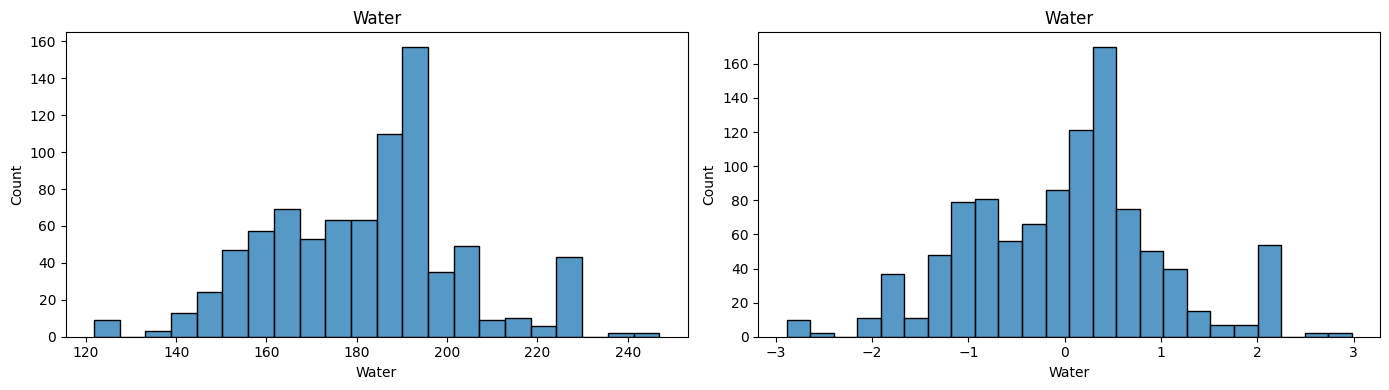

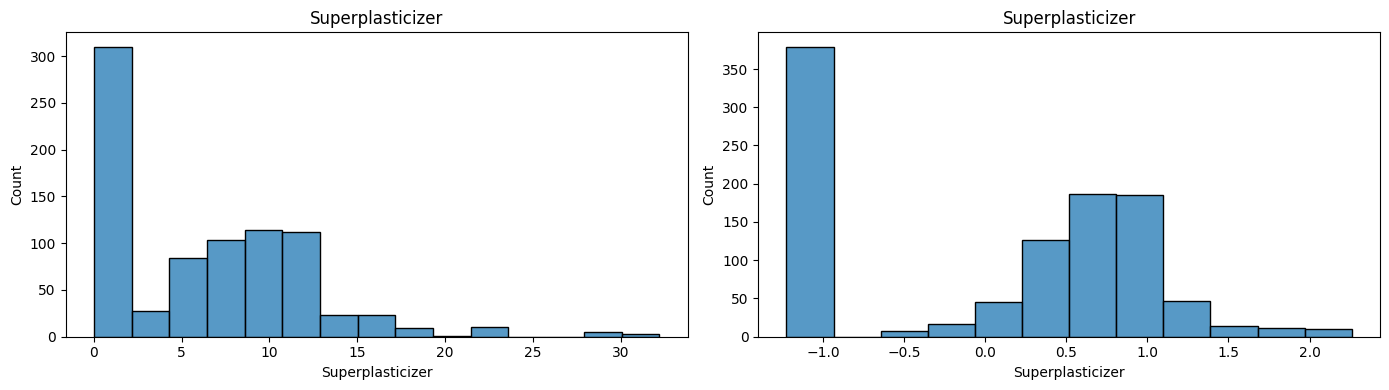

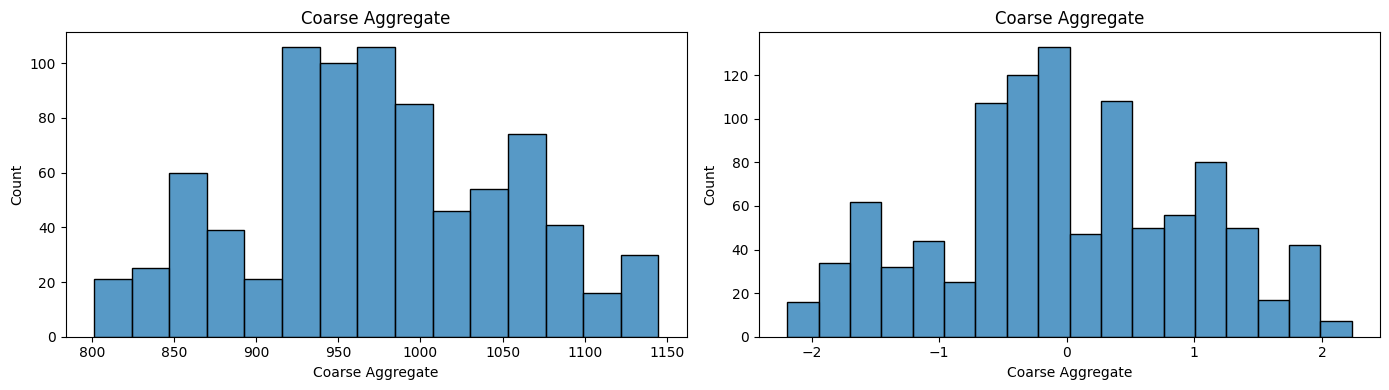

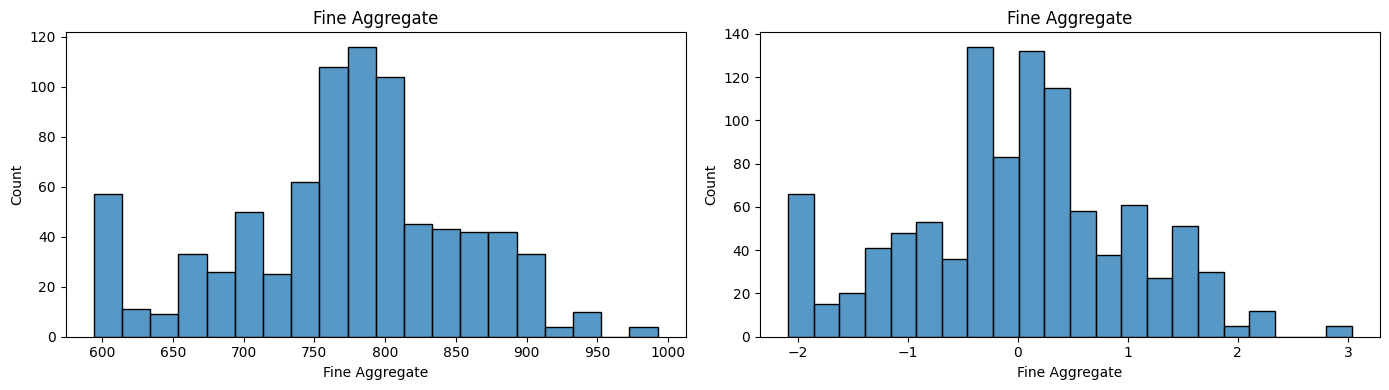

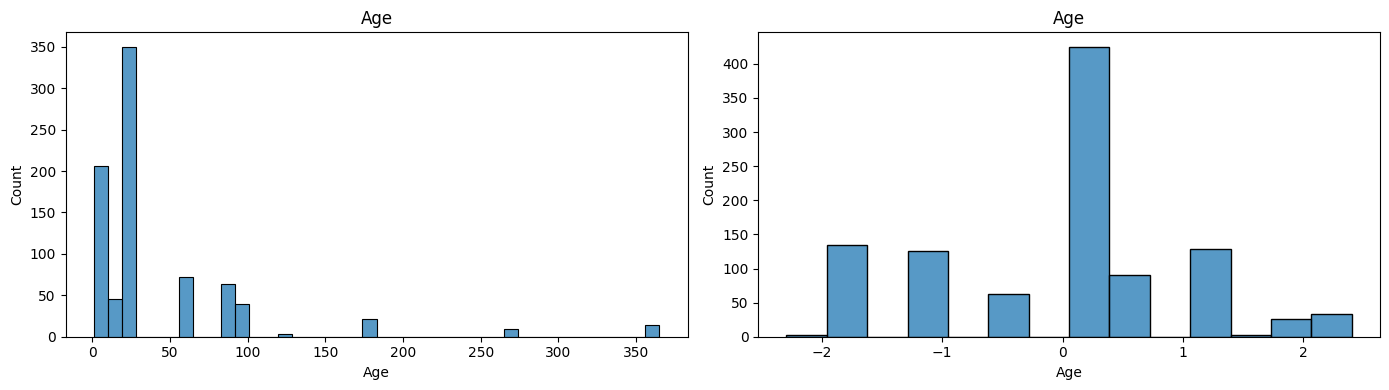

In [22]:
# before and after plot of yeo-johnson
for col in xtrain_trans.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(xtrain[col])
    plt.title(col)

    plt.subplot(122)
    sns.histplot(xtrain_trans[col])
    plt.title(col)

    plt.tight_layout()
    plt.show()

In [23]:
# compare lambdas of both cox-box and yeo-johnson
pd.DataFrame({'cols': xtrain.columns, 'box_cox_lambdas': pt.lambdas_, 'yeo_johnson_lambdas': pt1.lambdas_ })

,cols,box_cox_lambdas,yeo_johnson_lambdas
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.028052,0.016633
2,Fly Ash,-0.037072,-0.136480
3,Water,0.809568,0.808438
4,Superplasticizer,0.114979,0.264160
5,Coarse Aggregate,1.129168,1.129395
6,Fine Aggregate,1.829625,1.830764
7,Age,0.048975,0.001771
